In [32]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [19]:
df = pd.read_csv("supply_chain.csv")

TARGET = "Disruption_Occurred"

CATEGORICAL = [
    "Origin_Port", "Destination_Port", "Transport_Mode",
    "Product_Category", "Weather_Condition"
]

NUMERIC = [
    "Distance_km", "Weight_MT", "Fuel_Price_Index",
    "Geopolitical_Risk_Score", "Carrier_Reliability_Score", "Lead_Time_Days"
]

print(df.head())
print("\nShape:", df.shape)
print("\nClass distribution:")
print(df[TARGET].value_counts())

  Shipment_ID        Date Origin_Port Destination_Port Transport_Mode  \
0    SC-10000  2025-10-16   Singapore      Los Angeles           Rail   
1    SC-10001  2024-04-24   Singapore         Shanghai           Rail   
2    SC-10002  2024-01-26   Rotterdam      Los Angeles           Rail   
3    SC-10003  2024-10-08       Busan          Hamburg           Rail   
4    SC-10004  2024-09-07       Busan        Singapore            Air   

  Product_Category  Distance_km  Weight_MT  Fuel_Price_Index  \
0         Textiles      5930.83     197.42              2.43   
1       Automotive     14285.36     237.24              2.30   
2      Perishables     11113.91     427.42              1.78   
3      Electronics      9180.55     170.66              3.20   
4      Perishables      2762.27     434.96              2.77   

   Geopolitical_Risk_Score Weather_Condition  Carrier_Reliability_Score  \
0                      5.0         Hurricane                      0.865   
1                      7.5

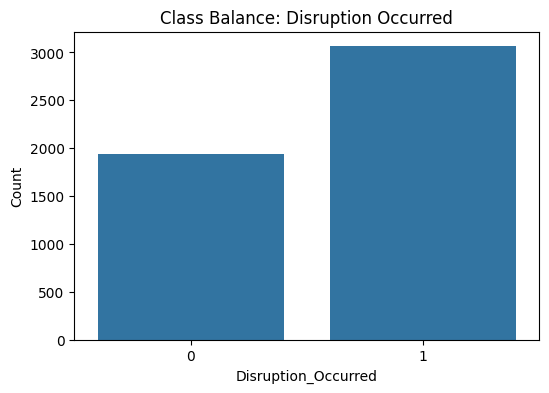

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Class Balance: Disruption Occurred")
plt.xlabel("Disruption_Occurred")
plt.ylabel("Count")
plt.show()

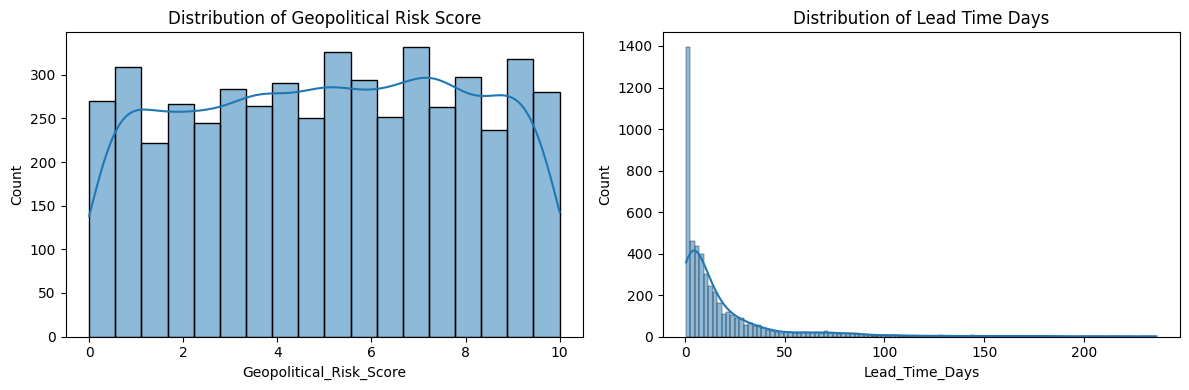

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="Geopolitical_Risk_Score", kde=True, ax=axes[0])
axes[0].set_title("Distribution of Geopolitical Risk Score")

sns.histplot(data=df, x="Lead_Time_Days", kde=True, ax=axes[1])
axes[1].set_title("Distribution of Lead Time Days")

plt.tight_layout()
plt.show()

In [23]:
X = df[CATEGORICAL + NUMERIC]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", "passthrough", NUMERIC)
])

model = Pipeline([
    ("prep", preprocessor),
    ("logreg", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Origin_Port',
                                                   'Destination_Port',
                                                   'Transport_Mode',
                                                   'Product_Category',
                                                   'Weather_Condition']),
                                                 ('num', 'passthrough',
                                                  ['Distance_km', 'Weight_MT',
                                                   'Fuel_Price_Index',
                                                   'Geopolitical_Risk_Score',
                                                   'Carrier_Reliability_Score',
                                                   'Lead_Time_Days'])])),
                ('logreg', LogisticRegression(max_iter=1000))])

In [27]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.752
ROC-AUC: 0.8435

Confusion Matrix:
[[265 114]
 [134 487]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       379
           1       0.81      0.78      0.80       621

    accuracy                           0.75      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.75      0.75      0.75      1000



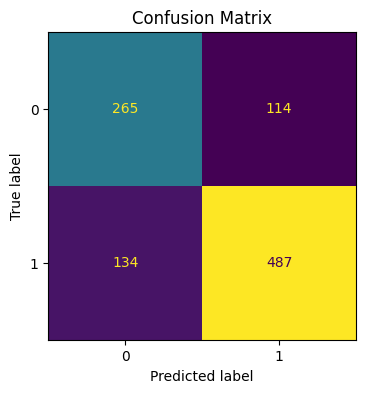

In [25]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

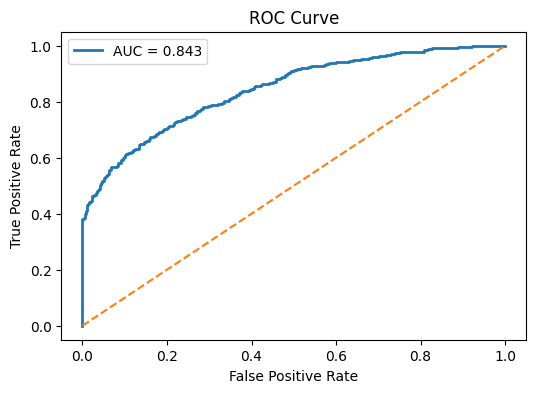

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

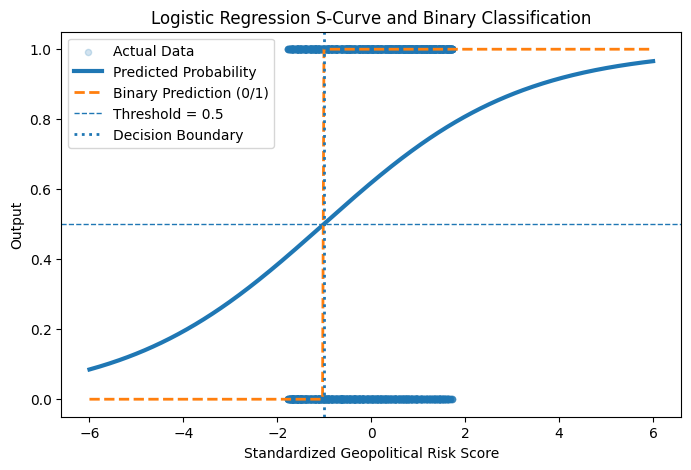

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# use one feature for a clean visualization
X_simple = df[["Geopolitical_Risk_Score"]]
y_simple = df[TARGET]

# scale the feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_simple)

# fit logistic regression
simple_model = LogisticRegression()
simple_model.fit(X_scaled, y_simple)

# create a smooth standardized x-range so the sigmoid is visible
z_range = np.linspace(-6, 6, 400).reshape(-1, 1)
prob_curve = simple_model.predict_proba(z_range)[:, 1]
class_curve = (prob_curve >= 0.5).astype(int)

# find decision boundary
boundary_index = np.argmin(np.abs(prob_curve - 0.5))
z_boundary = z_range[boundary_index][0]

# plot
plt.figure(figsize=(8, 5))

# actual binary data in scaled coordinates
plt.scatter(
    X_scaled,
    y_simple,
    alpha=0.2,
    s=20,
    label="Actual Data"
)

# probability S-curve
plt.plot(
    z_range,
    prob_curve,
    linewidth=3,
    label="Predicted Probability"
)

# binary classification step
plt.plot(
    z_range,
    class_curve,
    linestyle="--",
    linewidth=2,
    label="Binary Prediction (0/1)"
)

# threshold line
plt.axhline(0.5, linestyle="--", linewidth=1, label="Threshold = 0.5")

# decision boundary line
plt.axvline(z_boundary, linestyle=":", linewidth=2, label="Decision Boundary")

plt.title("Logistic Regression S-Curve and Binary Classification")
plt.xlabel("Standardized Geopolitical Risk Score")
plt.ylabel("Output")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()